**CO₂ Emission Prediction using Machine Learning**

**Business Objective**

Predict the **CO₂** emissions (g/km) of a vehicle using its engine specifications and fuel consumption data. This prediction can help manufacturers, researchers, and policymakers estimate environmental impact.

**Structue of Project**

**Data set Details**

**EDA**

**Model Building**

**Model Evaluation**

**Deployment**

***Data set Details***

**1: Import Required Libraries**

In [ ]:
# CO2 EMISSION PREDICTION PROJECT

# Data Manipulation Libraries
import pandas as pd
import numpy as np

# Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning Libraries
from sklearn.model_selection import train_test_split

# Display plots inside notebook
%matplotlib inline

# Set plotting style
plt.style.use('ggplot')
sns.set(font_scale=1.1)

print("Libraries Imported Successfully")  # Confirmation

Libraries Imported Successfully


**2: Load Dataset**

In [ ]:
# Read CSV File

from google.colab import files
uploaded = files.upload()
df = pd.read_csv('co2_emissions.csv')

# Display first five rows
df.head()

Saving co2_emissions.csv to co2_emissions.csv


,make,model,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_consumption_city,fuel_consumption_hwy,fuel_consumption_comb(l/100km),fuel_consumption_comb(mpg),co2_emissions
0,ACURA,ILX,COMPACT,2.0,4,AS,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS,Z,12.1,8.7,10.6,27,244


**3: Display Dataset Information**

In [ ]:
# Shape of Dataset
print("Shape of Dataset :", df.shape)

# Number of rows
print("Rows :", df.shape[0])

# Number of columns
print("Columns :", df.shape[1])



Shape of Dataset : (7385, 12)
Rows : 7385
Columns : 12


**4: Display First and Last Records**

In [ ]:
# First Five Records
df.head()

,make,model,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_consumption_city,fuel_consumption_hwy,fuel_consumption_comb(l/100km),fuel_consumption_comb(mpg),co2_emissions
0,ACURA,ILX,COMPACT,2.0,4,AS,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS,Z,12.1,8.7,10.6,27,244


In [ ]:
# Last Five Records
df.tail()

,make,model,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_consumption_city,fuel_consumption_hwy,fuel_consumption_comb(l/100km),fuel_consumption_comb(mpg),co2_emissions
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS,Z,10.7,7.7,9.4,30,219
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS,Z,11.2,8.3,9.9,29,232
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS,Z,11.7,8.6,10.3,27,240
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS,Z,11.2,8.3,9.9,29,232
7384,VOLVO,XC90 T6 AWD,SUV - STANDARD,2.0,4,AS,Z,12.2,8.7,10.7,26,248


**5: Column Names**

In [ ]:
# Display all column names

print(df.columns)

Index(['make', 'model', 'vehicle_class', 'engine_size', 'cylinders',
       'transmission', 'fuel_type', 'fuel_consumption_city',
       'fuel_consumption_hwy', 'fuel_consumption_comb(l/100km)',
       'fuel_consumption_comb(mpg)', 'co2_emissions'],
      dtype='object')


**6: Data Types**

In [ ]:
# Data Type of Every Column

df.dtypes

,0
make,object
model,object
vehicle_class,object
engine_size,float64
cylinders,int64
transmission,object
fuel_type,object
fuel_consumption_city,float64
fuel_consumption_hwy,float64
fuel_consumption_comb(l/100km),float64


**7: Complete Dataset Information**

In [ ]:
# Number of rows , Number of columns,Missing values,Data type,Memory usage

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   make                            7385 non-null   object 
 1   model                           7385 non-null   object 
 2   vehicle_class                   7385 non-null   object 
 3   engine_size                     7385 non-null   float64
 4   cylinders                       7385 non-null   int64  
 5   transmission                    7385 non-null   object 
 6   fuel_type                       7385 non-null   object 
 7   fuel_consumption_city           7385 non-null   float64
 8   fuel_consumption_hwy            7385 non-null   float64
 9   fuel_consumption_comb(l/100km)  7385 non-null   float64
 10  fuel_consumption_comb(mpg)      7385 non-null   int64  
 11  co2_emissions                   7385 non-null   int64  
dtypes: float64(4), int64(3), object(5)

**8: Summary Statistics**

In [ ]:
# Mean,Standard Deviation,Minimum,Maximum,Quartiles -summarized (numerical columns)
df.describe()

,engine_size,cylinders,fuel_consumption_city,fuel_consumption_hwy,fuel_consumption_comb(l/100km),fuel_consumption_comb(mpg),co2_emissions
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


**9: Statistical Summary Including Categorical Columns**

In [ ]:
df.describe(include='all') # shows categorical metrics (like unique, top, and freq)

,make,model,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_consumption_city,fuel_consumption_hwy,fuel_consumption_comb(l/100km),fuel_consumption_comb(mpg),co2_emissions
count,7385,7385,7385,7385.000000,7385.000000,7385,7385,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
unique,42,2053,16,NaN,NaN,5,5,NaN,NaN,NaN,NaN,NaN
top,FORD,F-150 FFV,SUV - SMALL,NaN,NaN,AS,X,NaN,NaN,NaN,NaN,NaN
freq,628,32,1217,NaN,NaN,3127,3637,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,3.160068,5.615030,NaN,NaN,12.556534,9.041706,10.975071,27.481652,250.584699
std,NaN,NaN,NaN,1.354170,1.828307,NaN,NaN,3.500274,2.224456,2.892506,7.231879,58.512679
min,NaN,NaN,NaN,0.900000,3.000000,NaN,NaN,4.200000,4.000000,4.100000,11.000000,96.000000
25%,NaN,NaN,NaN,2.000000,4.000000,NaN,NaN,10.100000,7.500000,8.900000,22.000000,208.000000
50%,NaN,NaN,NaN,3.000000,6.000000,NaN,NaN,12.100000,8.700000,10.600000,27.000000,246.000000
75%,NaN,NaN,NaN,3.700000,6.000000,NaN,NaN,14.600000,10.200000,12.600000,32.000000,288.000000


**10: Missing Values**

In [ ]:
df.isnull().sum() # total number of missing (null) values for each column

,0
make,0
model,0
vehicle_class,0
engine_size,0
cylinders,0
transmission,0
fuel_type,0
fuel_consumption_city,0
fuel_consumption_hwy,0
fuel_consumption_comb(l/100km),0


**Percentage of Missing Values**

In [ ]:
# missing = df.isnull().sum()
# percentage = (missing/len(df))*100

percentage = df.isnull().mean() * 100   # optimized the code to increse Efficiency
pd.DataFrame({
    "Missing Values":df.isnull().sum(),
    "Percentage":percentage
})

,Missing Values,Percentage
make,0,0.0
model,0,0.0
vehicle_class,0,0.0
engine_size,0,0.0
cylinders,0,0.0
transmission,0,0.0
fuel_type,0,0.0
fuel_consumption_city,0,0.0
fuel_consumption_hwy,0,0.0
fuel_consumption_comb(l/100km),0,0.0


**11: Duplicate Records**

In [ ]:
# Count
df.duplicated().sum()


np.int64(1112)

**Remove Duplicates**

In [ ]:
print("Old Shape :",df.shape)

df = df.drop_duplicates()

print("New Shape :",df.shape)   # After Removing duplicate showing the new shape

Old Shape : (7385, 12)
New Shape : (6273, 12)


**12: Unique Values**

In [ ]:
# Unique Values in Every Column

for col in df.columns:
    print("-"*60)
    print(col)
    print(df[col].nunique())

------------------------------------------------------------
make
42
------------------------------------------------------------
model
2053
------------------------------------------------------------
vehicle_class
16
------------------------------------------------------------
engine_size
51
------------------------------------------------------------
cylinders
8
------------------------------------------------------------
transmission
5
------------------------------------------------------------
fuel_type
5
------------------------------------------------------------
fuel_consumption_city
211
------------------------------------------------------------
fuel_consumption_hwy
143
------------------------------------------------------------
fuel_consumption_comb(l/100km)
181
------------------------------------------------------------
fuel_consumption_comb(mpg)
54
------------------------------------------------------------
co2_emissions
331


**13: Display Unique Categories**

In [ ]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print("="*60)
    print(col)
    print(df[col].unique())    # Actual variables
    print("Total Distinct Values in",col,": ",df[col].nunique())   # Count of distinct values

make
['ACURA' 'ALFA ROMEO' 'ASTON MARTIN' 'AUDI' 'BENTLEY' 'BMW' 'BUICK'
 'CADILLAC' 'CHEVROLET' 'CHRYSLER' 'DODGE' 'FIAT' 'FORD' 'GMC' 'HONDA'
 'HYUNDAI' 'INFINITI' 'JAGUAR' 'JEEP' 'KIA' 'LAMBORGHINI' 'LAND ROVER'
 'LEXUS' 'LINCOLN' 'MASERATI' 'MAZDA' 'MERCEDES-BENZ' 'MINI' 'MITSUBISHI'
 'NISSAN' 'PORSCHE' 'RAM' 'ROLLS-ROYCE' 'SCION' 'SMART' 'SRT' 'SUBARU'
 'TOYOTA' 'VOLKSWAGEN' 'VOLVO' 'GENESIS' 'BUGATTI']
Total Distinct Values in make :  42
model
['ILX' 'ILX HYBRID' 'MDX 4WD' ... 'Tacoma 4WD D-Cab TRD Off-Road/Pro'
 'Atlas Cross Sport 4MOTION' 'XC40 T4 AWD']
Total Distinct Values in model :  2053
vehicle_class
['COMPACT' 'SUV - SMALL' 'MID-SIZE' 'TWO-SEATER' 'MINICOMPACT'
 'SUBCOMPACT' 'FULL-SIZE' 'STATION WAGON - SMALL' 'SUV - STANDARD'
 'VAN - CARGO' 'VAN - PASSENGER' 'PICKUP TRUCK - STANDARD' 'MINIVAN'
 'SPECIAL PURPOSE VEHICLE' 'STATION WAGON - MID-SIZE'
 'PICKUP TRUCK - SMALL']
Total Distinct Values in vehicle_class :  16
transmission
['AS' 'M' 'AV' 'AM' 'A']
Total Distinct Val

**14: Separate Numerical and Categorical Columns**

In [ ]:
numerical_columns = df.select_dtypes(include=np.number).columns

categorical_columns = df.select_dtypes(include='object').columns

print("Numerical Columns")

print(numerical_columns)

print()   # for space

print("Categorical Columns")

print(categorical_columns)

Numerical Columns
Index(['engine_size', 'cylinders', 'fuel_consumption_city',
       'fuel_consumption_hwy', 'fuel_consumption_comb(l/100km)',
       'fuel_consumption_comb(mpg)', 'co2_emissions'],
      dtype='object')

Categorical Columns
Index(['make', 'model', 'vehicle_class', 'transmission', 'fuel_type'], dtype='object')


**15: Data Distribution**

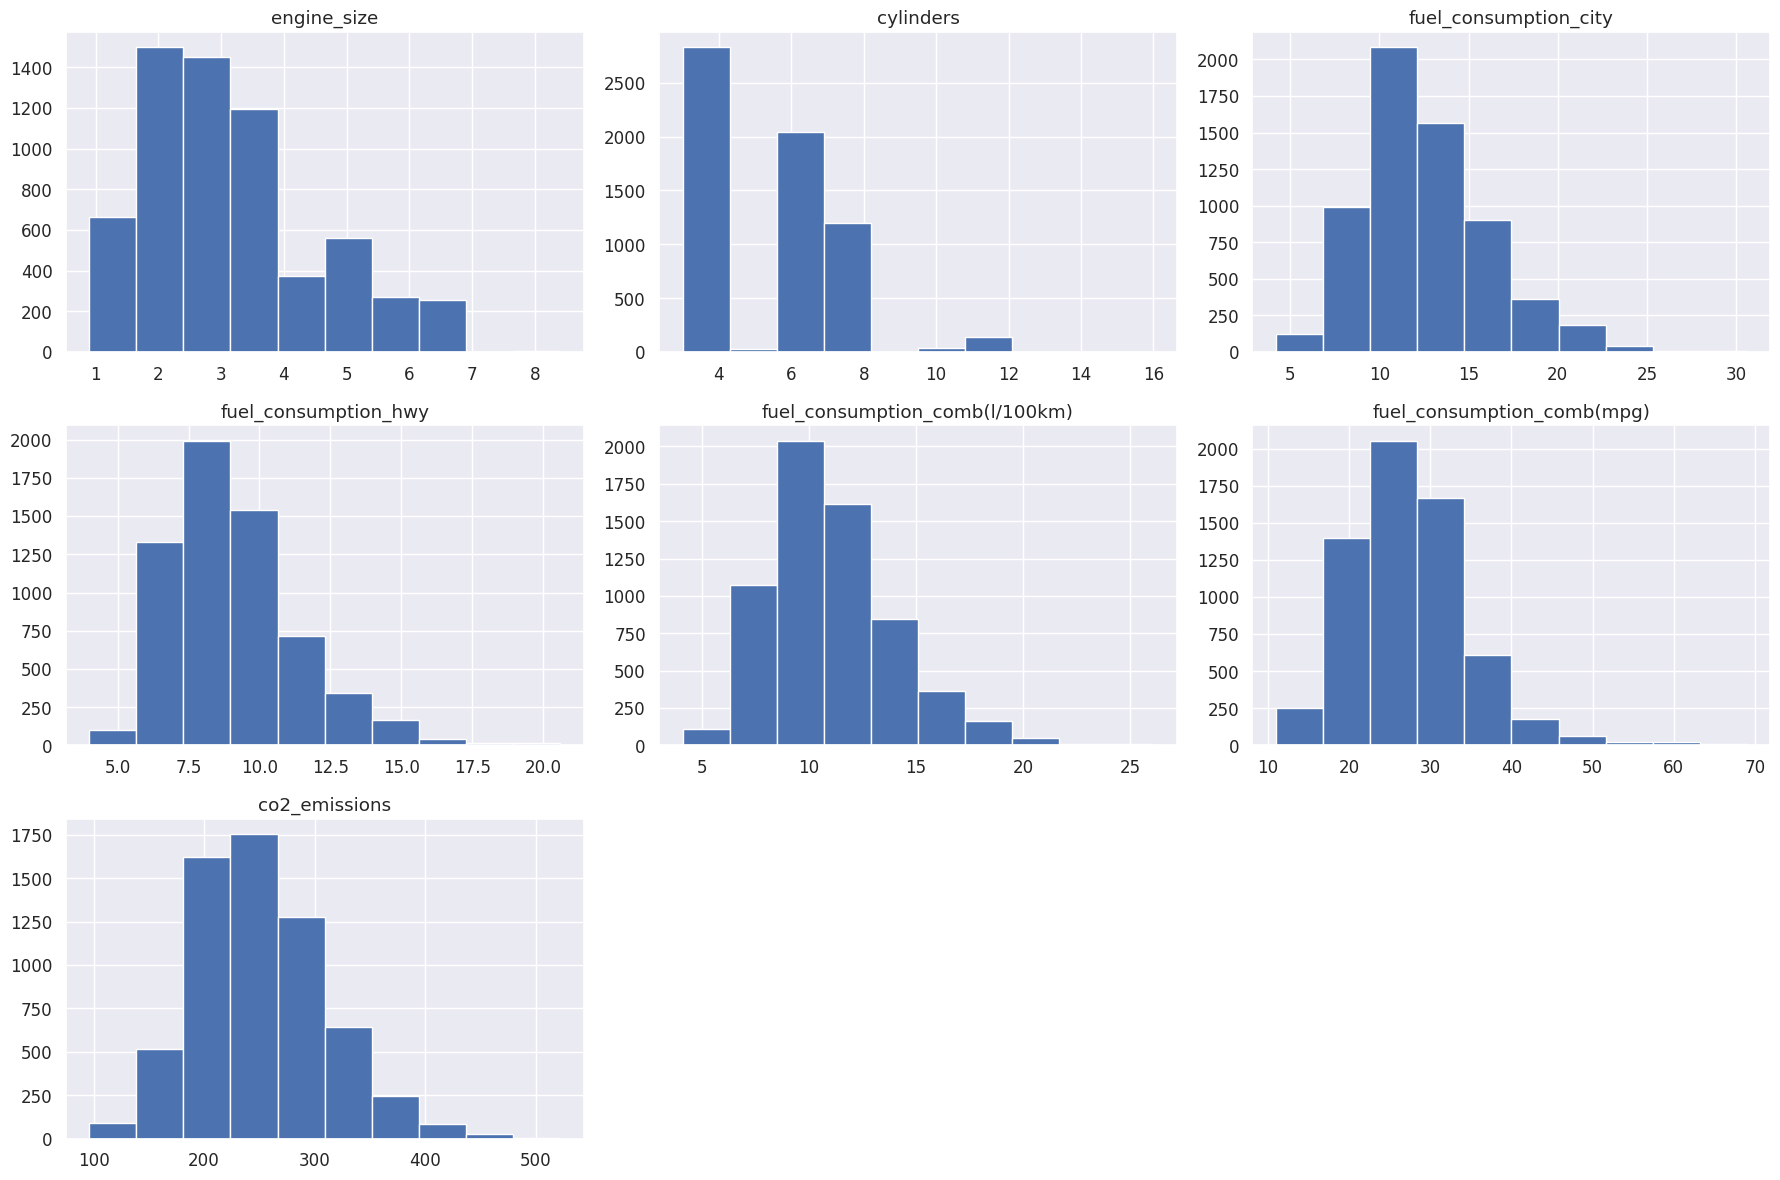

In [ ]:
df.hist(figsize=(18,12))

plt.tight_layout()

plt.show()

**Interpretation**

Normal distributions,
Skewed distributions,
Outliers,
Spread of values

**Exploratory Data Analysis (EDA)**

In [ ]:
# Separate Numerical and Categorical Features

num_cols = df.select_dtypes(include=['int64','float64']).columns

cat_cols = df.select_dtypes(include='object').columns

print("Numerical Columns")
print(num_cols)
print()
print("\nCategorical Columns")
print(cat_cols)

Numerical Columns
Index(['engine_size', 'cylinders', 'fuel_consumption_city',
       'fuel_consumption_hwy', 'fuel_consumption_comb(l/100km)',
       'fuel_consumption_comb(mpg)', 'co2_emissions'],
      dtype='object')


Categorical Columns
Index(['make', 'model', 'vehicle_class', 'transmission', 'fuel_type'], dtype='object')


** Engine Size Distribution **

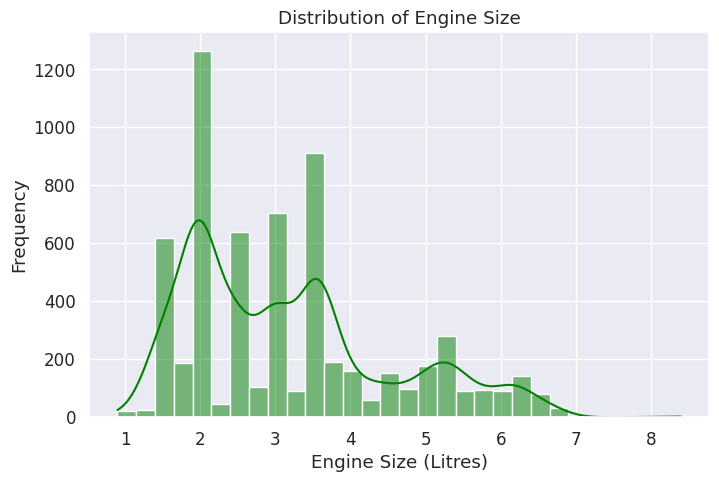

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['engine_size'],
             bins=30,
             kde=True,
             color='green')

plt.title("Distribution of Engine Size")
plt.xlabel("Engine Size (Litres)")
plt.ylabel("Frequency")

plt.show()

**Insight :**
Most cars have engines between **2L and 4L.**
Very large engines are **rare**.
slightly** right-skewed** distribution

**2. CO₂ Emission Distribution**

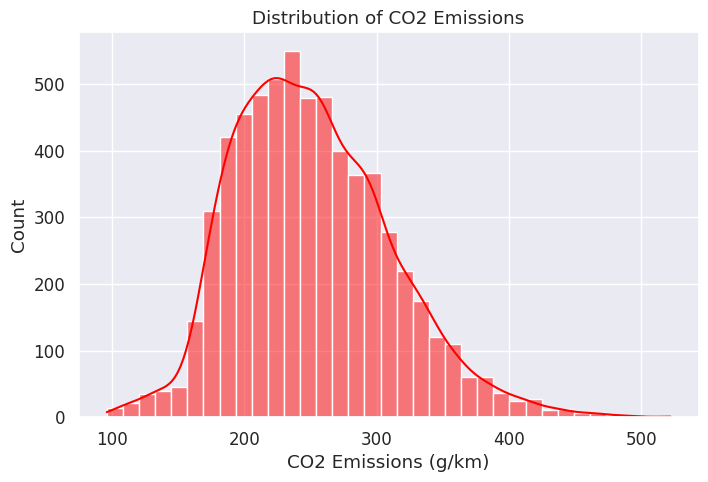

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['co2_emissions'],
             bins=35,
             kde=True,
             color='Red')

plt.title("Distribution of CO2 Emissions")
plt.xlabel("CO2 Emissions (g/km)")
plt.ylabel("Count")

plt.show()

**Insight**
Most vehicles emit between **180–300 g/km.**
Very low emission vehicles are limited.
A few high-emission outliers exist.

**3 Boxplot for Engine Size**

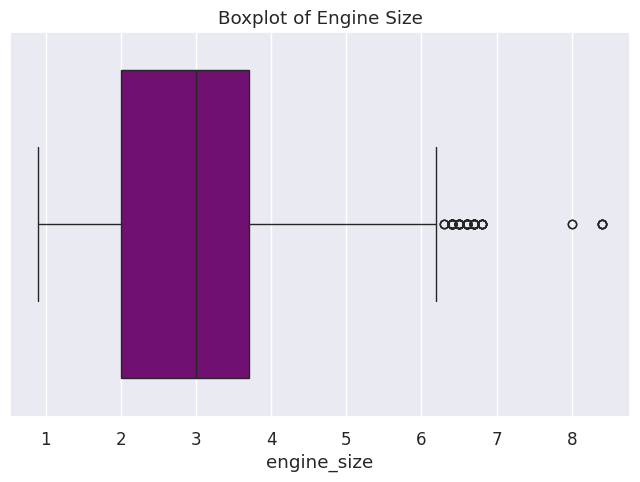

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['engine_size'],
            color='purple')

plt.title("Boxplot of Engine Size")

plt.show()

**Insight**

**Outliers** Detected

**Large engine** vehicles appear as outliers.

**4 Boxplot for CO₂**

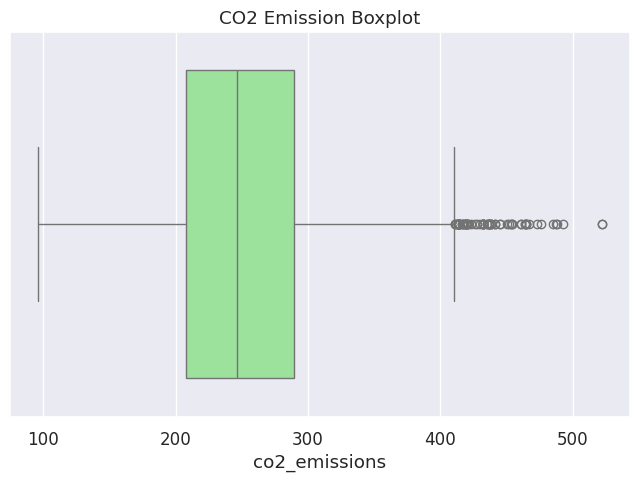

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['co2_emissions'],
            color='lightgreen')

plt.title("CO2 Emission Boxplot")

plt.show()

**Insight**

*   **Median CO2 emissions**: Around 240-250 g/km. Most vehicles fall within this range.
*   **Interquartile Range (IQR)**: The bulk of CO2 emissions are concentrated between approximately 200 g/km and 290 g/km.
*   **Outliers**: A significant number of vehicles with CO2 emissions. This suggests that while most cars are within a certain emission range
*   **Skewness**: slightly right-skewed, indicating a tail of **higher** emission values, which is consistent with the presence of **upper outliers**.

**5 Count Plot of Vehicle Class**

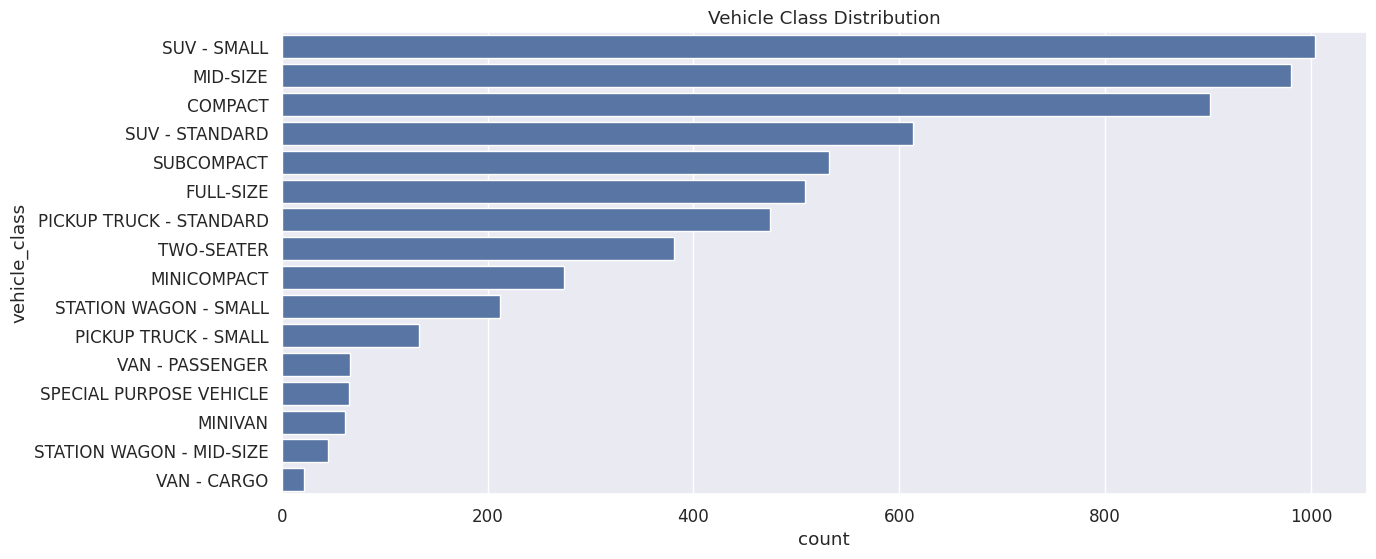

In [ ]:
plt.figure(figsize=(14,6))

sns.countplot(
    y='vehicle_class',
    data=df,
    order=df['vehicle_class'].value_counts().index
)

plt.title("Vehicle Class Distribution")

plt.show()

**Insight**

most common vehicle types

**SUVs** and **Compact** cars dominate the dataset.

**6 Fuel Type Distribution**

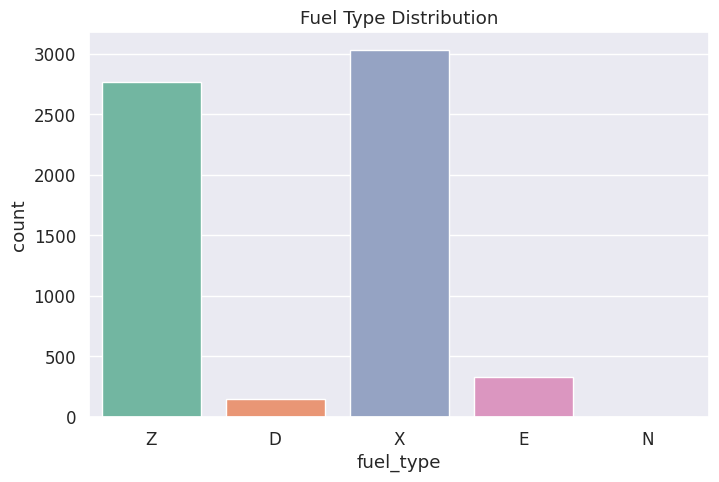

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='fuel_type',
    data=df,
    palette='Set2'
)

plt.title("Fuel Type Distribution")

plt.show()

**Fuel Codes**

**Code with meaning**

X	Regular

Z	Premium

D	Diesel

E	E85

N	Natural Gas

**7 Transmission Distribution**

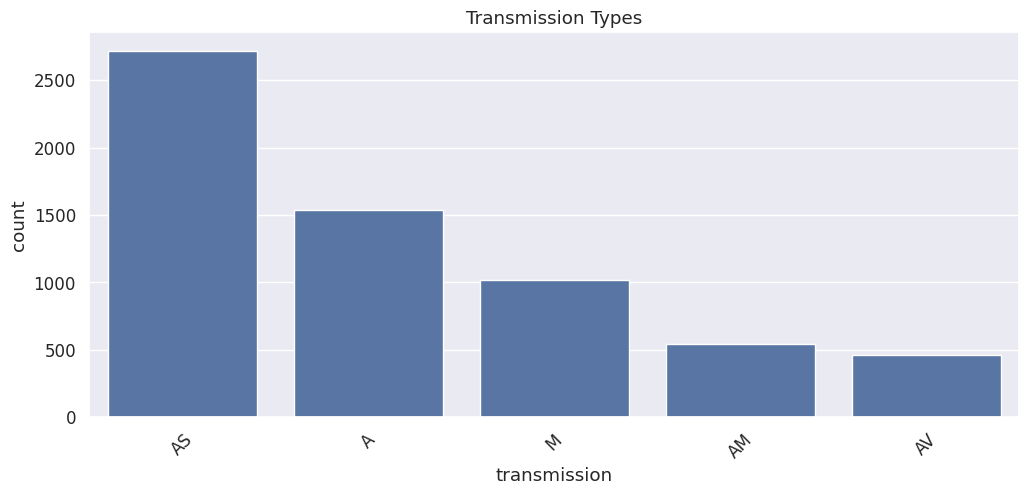

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='transmission',
    data=df,
    order=df['transmission'].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Transmission Types")

plt.show()

##**BIVARIATE ANALYSIS**

(Relationship between two variables)

**8 Engine Size vs CO₂**

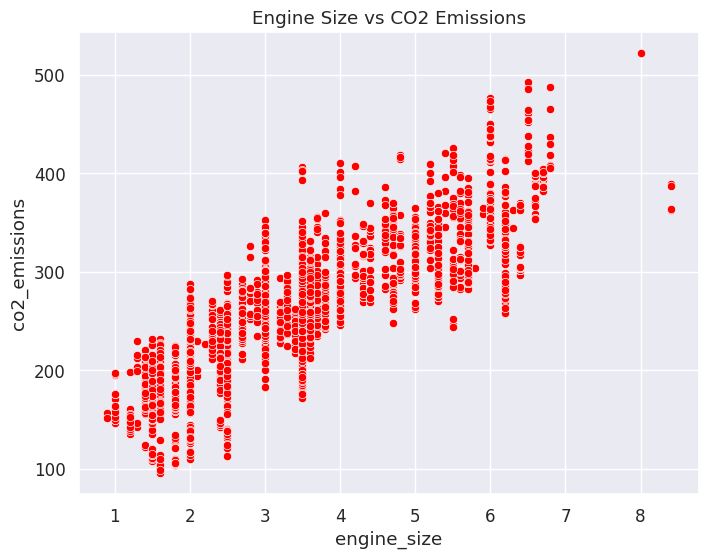

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='engine_size',
    y='co2_emissions',
    data=df,
    color='red'
)

plt.title("Engine Size vs CO2 Emissions")

plt.show()

**Insight**

Strong **positive** relationship between engine size and CO₂ emissions.

**9 Cylinders vs CO₂**

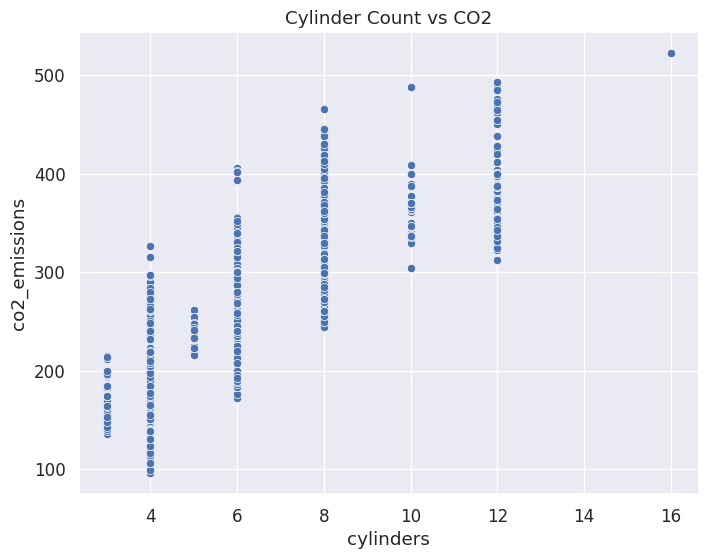

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='cylinders',
    y='co2_emissions',
    data=df
)

plt.title("Cylinder Count vs CO2")

plt.show()

**Insight**

Vehicles with **more cylinders** generally **emit more CO₂**.

**10 Combined Fuel Consumption vs CO₂**

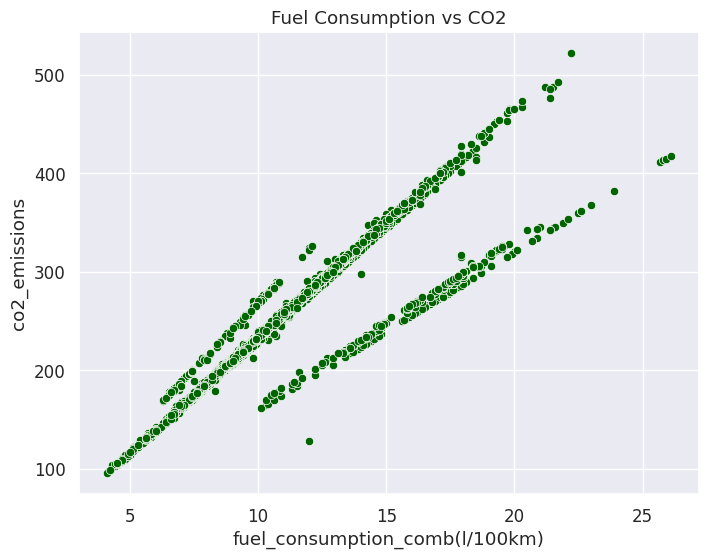

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='fuel_consumption_comb(l/100km)',
    y='co2_emissions',
    data=df,
    color='darkgreen'
)

plt.title("Fuel Consumption vs CO2")

plt.show()

**Insight**

Higher fuel **consumption** leads to **higher** CO₂ **emissions**.

**11 Highway Consumption vs CO₂**

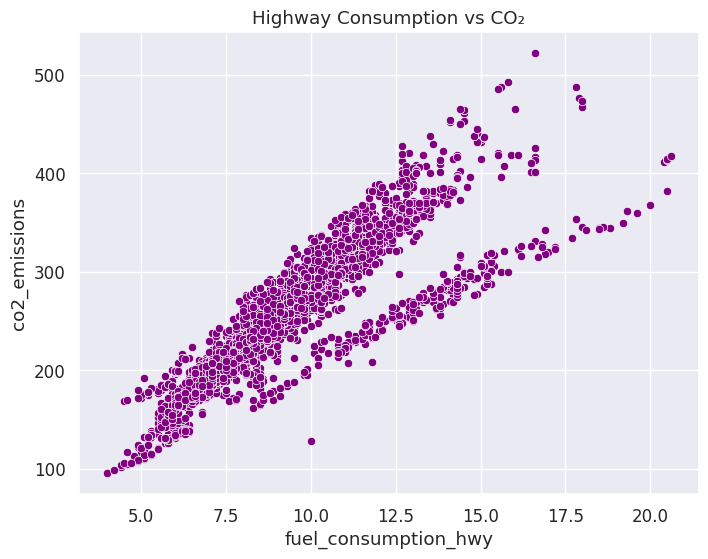

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='fuel_consumption_hwy',
    y='co2_emissions',
    data=df,
    color='purple'
)
plt.title("Highway Consumption vs CO₂")
plt.show()

**Insight**

There is a strong positive correlation between highway fuel consumption and CO₂ emissions. Higher highway consumption directly leads to increased CO₂ output.

**12 City Consumption vs CO₂**

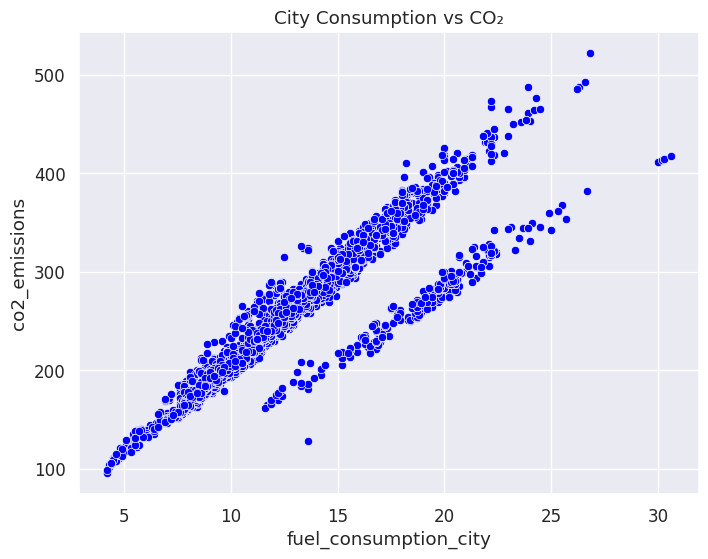

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='fuel_consumption_city',
    y='co2_emissions',
    data=df,
    color='blue'
)
plt.title("City Consumption vs CO₂")
plt.show()

**Insight**

Similar to highway consumption, city fuel consumption shows a clear positive relationship with CO₂ emissions. Vehicles with higher city fuel consumption also produce more CO₂.

**13 Boxplot of CO₂ by Fuel Type**

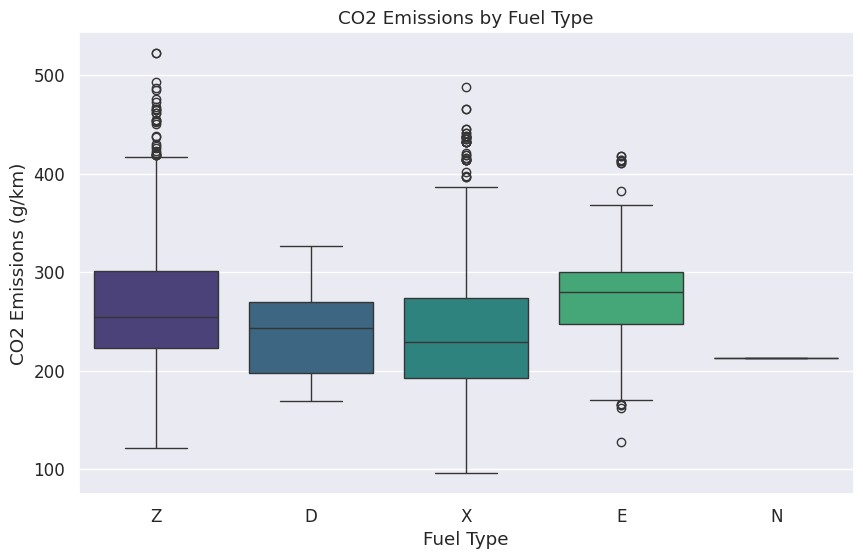

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='fuel_type', y='co2_emissions', data=df, palette='viridis')
plt.title('CO2 Emissions by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('CO2 Emissions (g/km)')
plt.show()

**Insight**

*   **Fuel Type 'D' (Diesel)**: Higher CO2 emissions on average, shows some high outliers.
*   **Fuel Type 'E' (E85 Ethanol)**: lower median CO2 emission, few outliers.
*   **Fuel Type 'N' (Natural Gas)**:
Lowest CO2 emissions, and no significant outliers.
*   **Fuel Types 'X' (Regular) and 'Z' (Premium)**: These two fuel types show similar distributions, Both have a considerable number of vehicles with higher CO2 emissions

**14: Correlation between Fuel Consumption and CO₂ Emissions**

Correlation between Fuel Consumption and CO₂ Emissions:


,co2_emissions
fuel_consumption_city,0.918528
fuel_consumption_hwy,0.883153
fuel_consumption_comb(l/100km),0.916611
fuel_consumption_comb(mpg),-0.906839


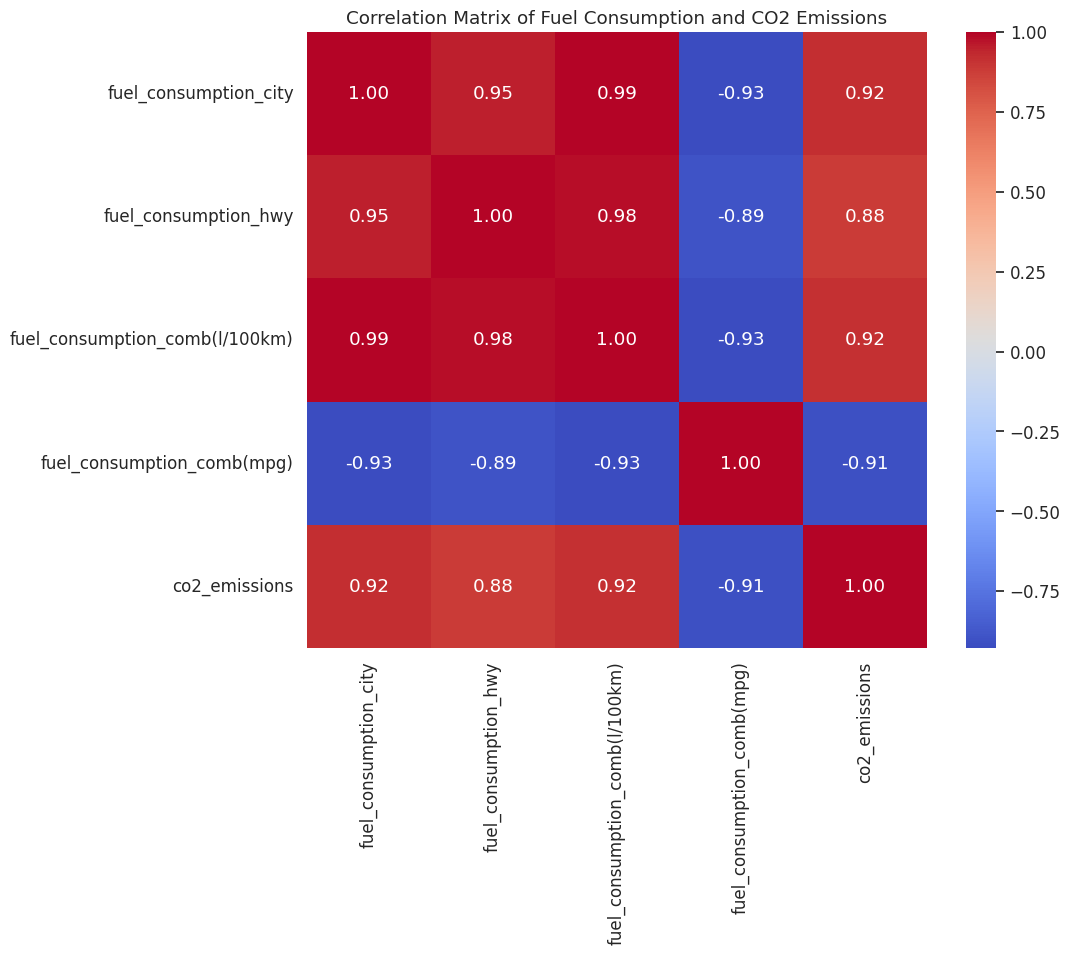

In [ ]:
correlation_matrix = df[['fuel_consumption_city', 'fuel_consumption_hwy', 'fuel_consumption_comb(l/100km)', 'fuel_consumption_comb(mpg)', 'co2_emissions']].corr()

print("Correlation between Fuel Consumption and CO₂ Emissions:")
display(correlation_matrix['co2_emissions'].drop('co2_emissions'))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Fuel Consumption and CO2 Emissions')
plt.show()

**15 CO₂ by Vehicle Class**

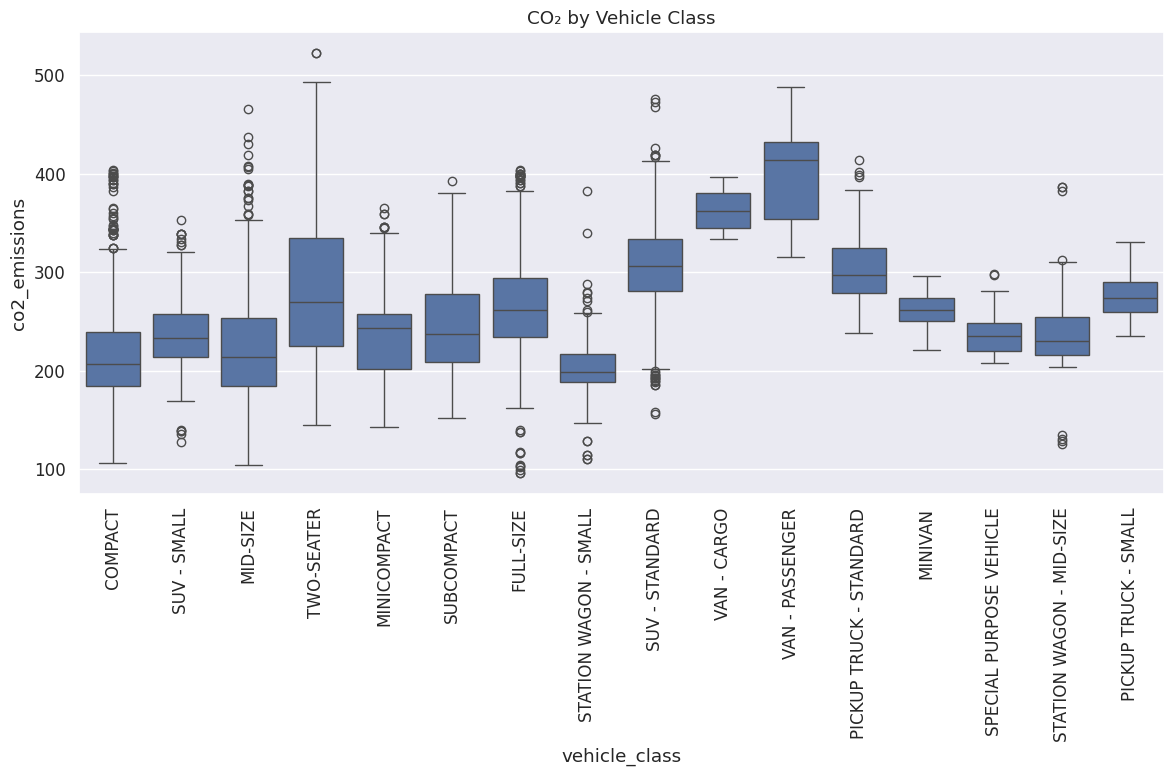

In [ ]:
plt.figure(figsize=(14,6))

sns.boxplot(
    x='vehicle_class',
    y='co2_emissions',
    data=df
)

plt.xticks(rotation=90)
plt.title("CO₂ by Vehicle Class")
plt.show()

**Insight**: 'VAN - **PASSENGER**' and 'VAN - **CARGO**' vehicle classes tend to have the **highest** CO₂ emissions, while '**MINICOMPACT**' and '**TWO-SEATER**' classes have **lower** emissions.

##**MULTIVARIATE ANALYSIS**

**16 Correlation Heatmap**

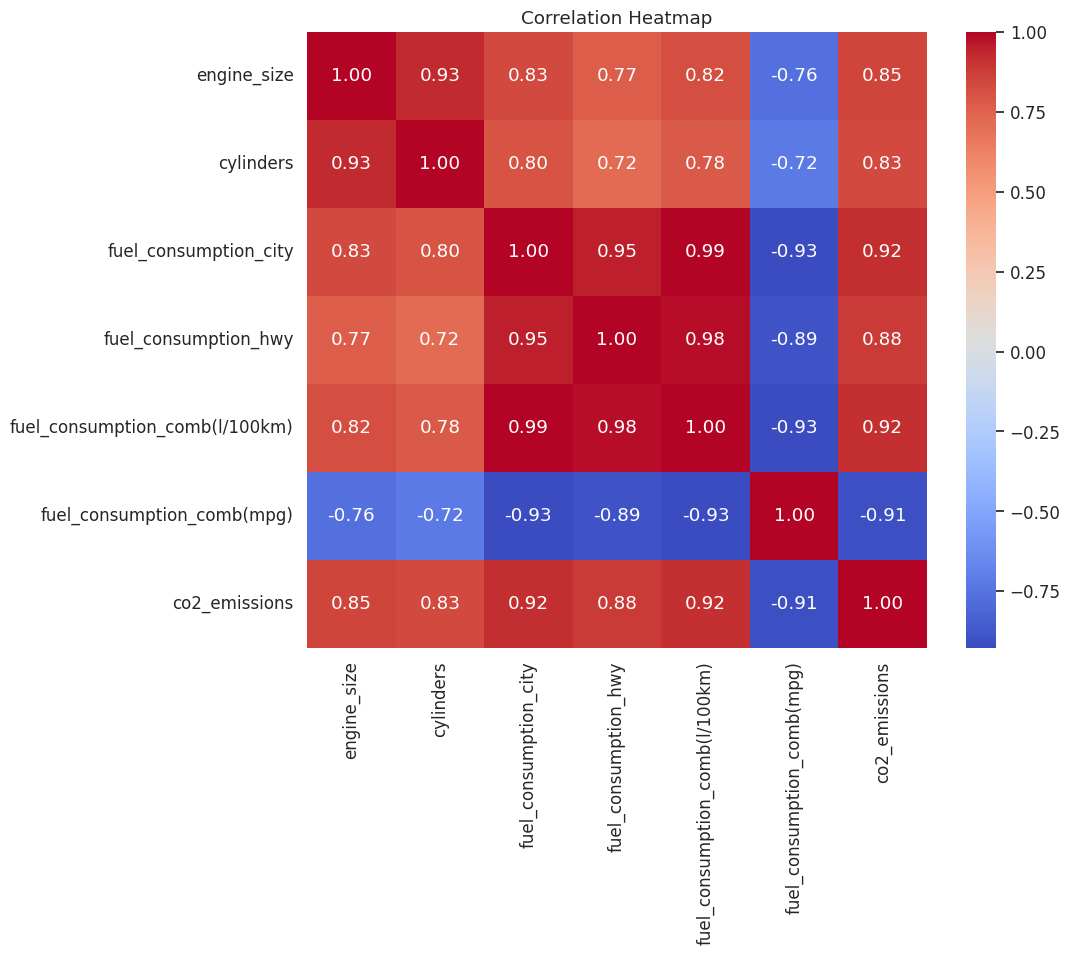

In [ ]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

**Insight**

Need to look for features with the **highest** **positive** or **negative** correlation with co2_emissions.

**17 Pairplot**

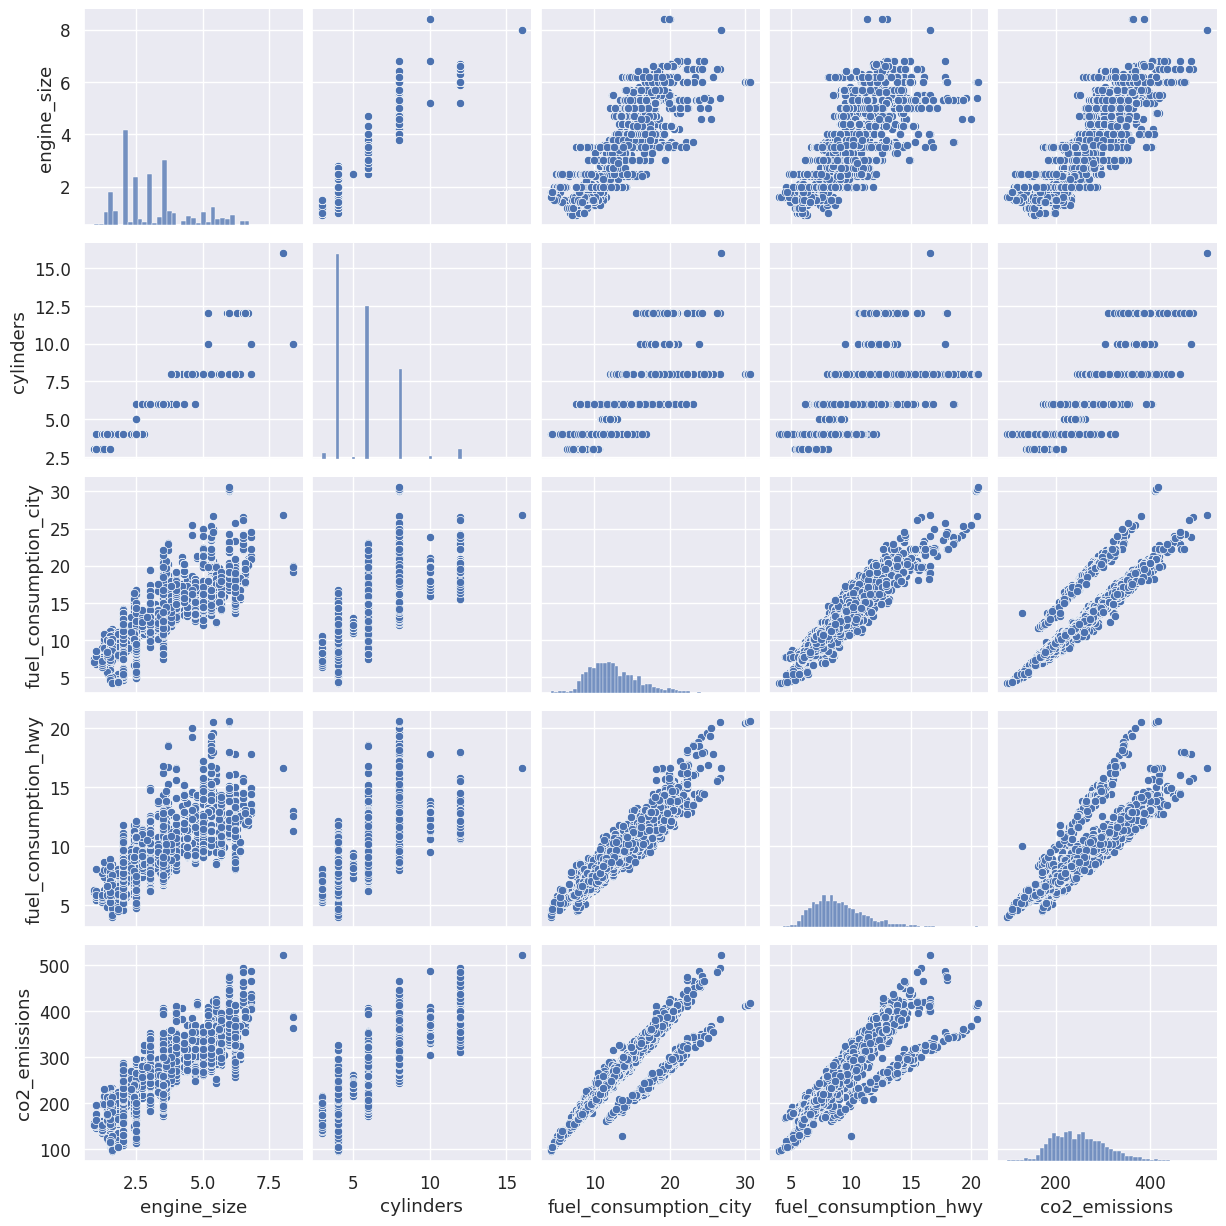

In [ ]:
sns.pairplot(
    df[[
        'engine_size',
        'cylinders',
        'fuel_consumption_city',
        'fuel_consumption_hwy',
        'co2_emissions'
    ]]
)

plt.show()

**Insight**

Visualize relationships between multiple numerical variables simultaneously.

**18 Average CO₂ by Fuel Type**

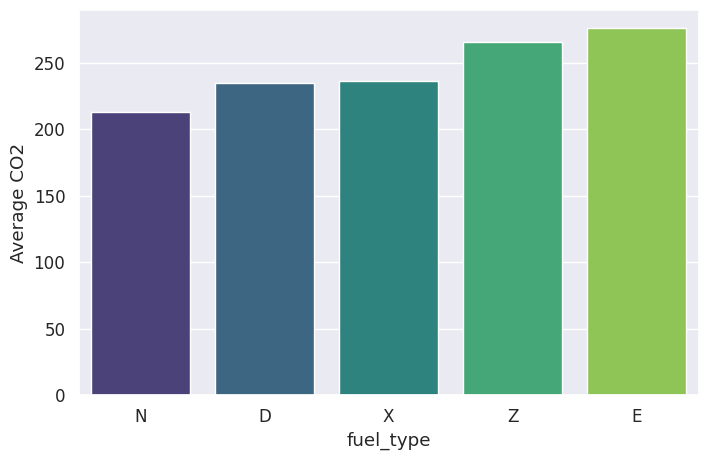

In [ ]:
avg = df.groupby('fuel_type')['co2_emissions'].mean().sort_values()

plt.figure(figsize=(8,5))

sns.barplot(
    x=avg.index,
    y=avg.values,
    palette='viridis'
)

plt.ylabel("Average CO2")

plt.show()

**Insight**: Natural Gas (N) fuel type shows the lowest average CO₂ emissions, while E85 Ethanol (E) and Premium (Z) fuel types have the highest average CO₂ emissions.

**19 Top 10 Car Manufacturers**

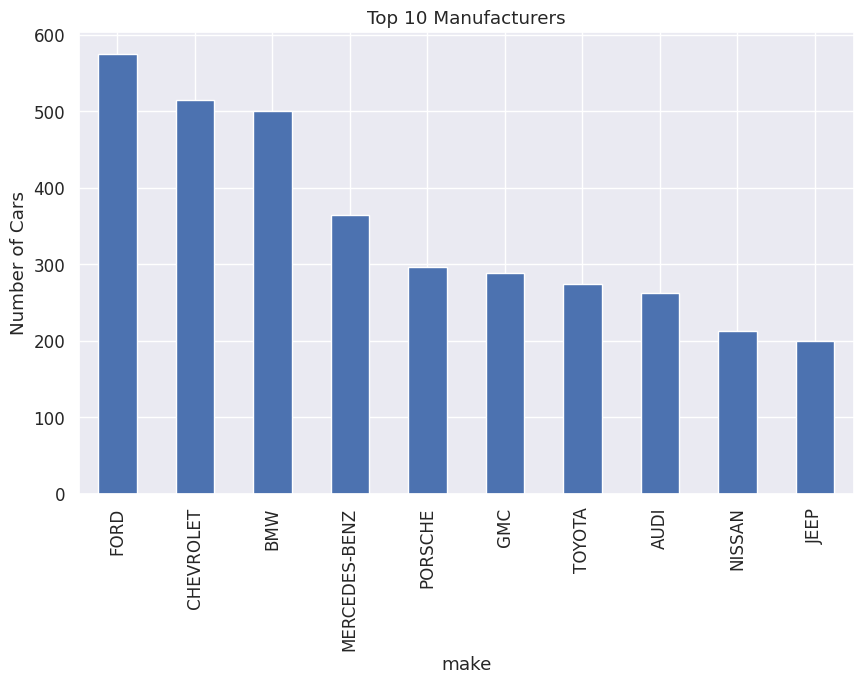

In [ ]:
plt.figure(figsize=(10,6))

df['make'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Manufacturers")

plt.ylabel("Number of Cars")

plt.show()

**20 Average CO₂ by Manufacturer**

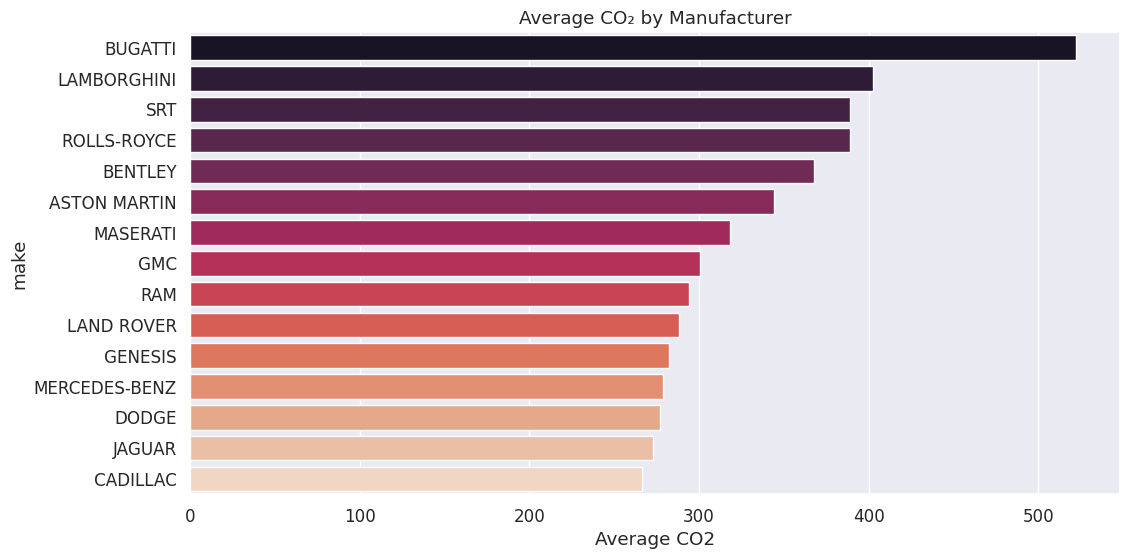

In [ ]:
top_make = df.groupby('make')['co2_emissions'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_make.values,
    y=top_make.index,
    palette='rocket'
)

plt.xlabel("Average CO2")
plt.title("Average CO₂ by Manufacturer")
plt.show()

**21 Correlation with Target**

In [ ]:
corr = df.corr(numeric_only=True)
corr_target = corr ['co2_emissions'].sort_values(ascending=False)

print(corr_target)

co2_emissions                     1.000000
fuel_consumption_city             0.918528
fuel_consumption_comb(l/100km)    0.916611
fuel_consumption_hwy              0.883153
engine_size                       0.854999
cylinders                         0.834697
fuel_consumption_comb(mpg)       -0.906839
Name: co2_emissions, dtype: float64


**EDA Insights**

1. Engine Size has a strong positive correlation with CO₂ emissions.

2. Fuel Consumption is one of the strongest predictors of CO₂ emissions.

3. Vehicles with more cylinders generally produce more emissions.

4. SUVs and larger vehicle classes emit more CO₂ than compact cars.

5. Diesel and premium fuel vehicles show different emission patterns compared to regular gasoline.

6. Some outliers exist for engine size and emissions, but represent high-performance vehicles and should be checked before removal.

7. Fuel consumption and engine characteristics together plays a large portion of the variation in CO₂ emissions.

##**DATA PREPROCESSING**

**1: Make a Copy of Dataset**

In [ ]:
# Make a copy of original dataset

df1 = df.copy()

print("Dataset copied successfully.")

Dataset copied successfully.


 **2: Check Missing Values Again**





In [ ]:
missing = df1.isnull().sum()

missing_df = pd.DataFrame({
    "Columns":missing.index,
    "Missing Values":missing.values,
    "Percentage":(missing / len(df1) * 100).round(2)
})

missing_df

,Columns,Missing Values,Percentage
make,make,0,0.0
model,model,0,0.0
vehicle_class,vehicle_class,0,0.0
engine_size,engine_size,0,0.0
cylinders,cylinders,0,0.0
transmission,transmission,0,0.0
fuel_type,fuel_type,0,0.0
fuel_consumption_city,fuel_consumption_city,0,0.0
fuel_consumption_hwy,fuel_consumption_hwy,0,0.0
fuel_consumption_comb(l/100km),fuel_consumption_comb(l/100km),0,0.0


**3: Handle Missing Values**

In [ ]:
# Numerical columns

num_cols = df1.select_dtypes(include=['int64','float64']).columns

for col in num_cols:

    df1[col].fillna(df1[col].median(), inplace=True)

Median is robust to outliers and often preferred for skewed numerical data.

**Categorical Columns**

In [ ]:
# Categorical columns

cat_cols = df1.select_dtypes(include='object').columns

for col in cat_cols:

    df1[col].fillna(df1[col].mode()[0], inplace=True)

**Verify**


In [ ]:
df1.isnull().sum()

,0
make,0
model,0
vehicle_class,0
engine_size,0
cylinders,0
transmission,0
fuel_type,0
fuel_consumption_city,0
fuel_consumption_hwy,0
fuel_consumption_comb(l/100km),0


**Expected Output**

All zeros

**4: Duplicate Records**

In [ ]:
duplicates = df1.duplicated().sum()

print("Duplicate Records :",duplicates)

Duplicate Records : 0


**Remove duplicates**

In [ ]:
df1.drop_duplicates(inplace=True)

print(df1.shape)

(6273, 12)


Duplicate observations can bias the model by giving extra weight to repeated data.

**5: Detect Outliers**

Use the **Interquartile Range (IQR)** method because it is simple and robust.

**Function for Outlier Detection**

In [ ]:
def detect_outliers(column):

    Q1 = df1[column].quantile(0.25)

    Q3 = df1[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR

    upper = Q3 + 1.5*IQR

    outliers = df1[(df1[column] < lower) | (df1[column] > upper)]

    return len(outliers)

**Count Outliers**

In [ ]:
for col in num_cols:

    print(col,"=",detect_outliers(col))

engine_size = 121
cylinders = 177
fuel_consumption_city = 116
fuel_consumption_hwy = 150
fuel_consumption_comb(l/100km) = 115
fuel_consumption_comb(mpg) = 93
co2_emissions = 74


**6: Visualize Outliers**

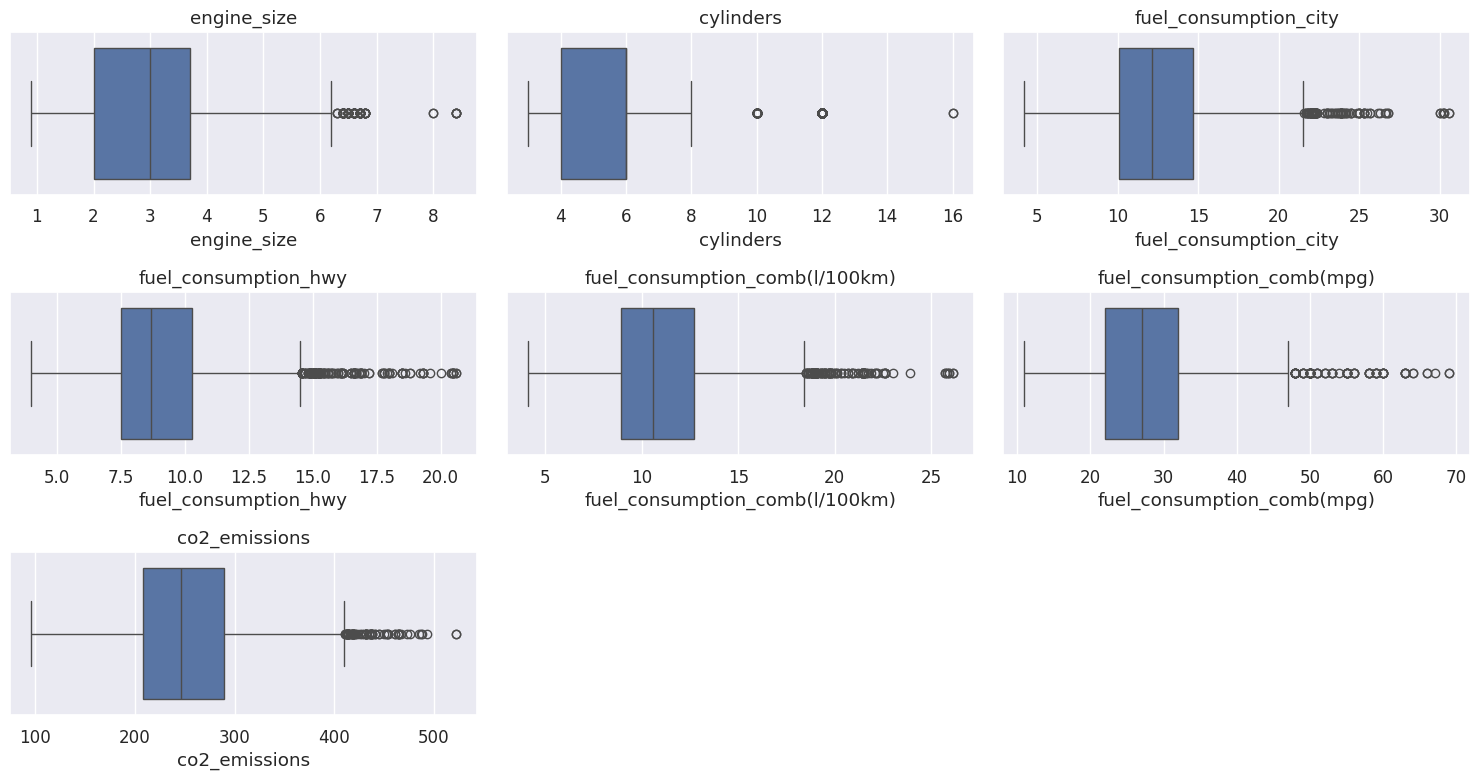

In [ ]:
plt.figure(figsize=(15,8))

for i,col in enumerate(num_cols):

    plt.subplot(3,3,i+1)

    sns.boxplot(x=df1[col])

    plt.title(col)

plt.tight_layout()

plt.show()

**As we know** Not every outlier should be removed.

In this dataset:

High engine size vehicles
Sports cars
Luxury cars

are genuine observations, not data entry errors.

Hence,

We will **cap** extreme values instead of removing rows.

**7: Outlier Treatment (Winsorization)**

In [ ]:
for col in num_cols:

    Q1 = df1[col].quantile(0.25)

    Q3 = df1[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR

    upper = Q3 + 1.5*IQR

    df1[col] = np.where(df1[col] < lower,
                        lower,
                        df1[col])

    df1[col] = np.where(df1[col] > upper,
                        upper,
                        df1[col])

Reason to choose **Winsorization**?

Instead of **deleting** valuable data, we **replace** extreme values with acceptable **limits**.

This preserves dataset size while reducing the **influence** of extreme observations.

**8: Verify Outliers Again**

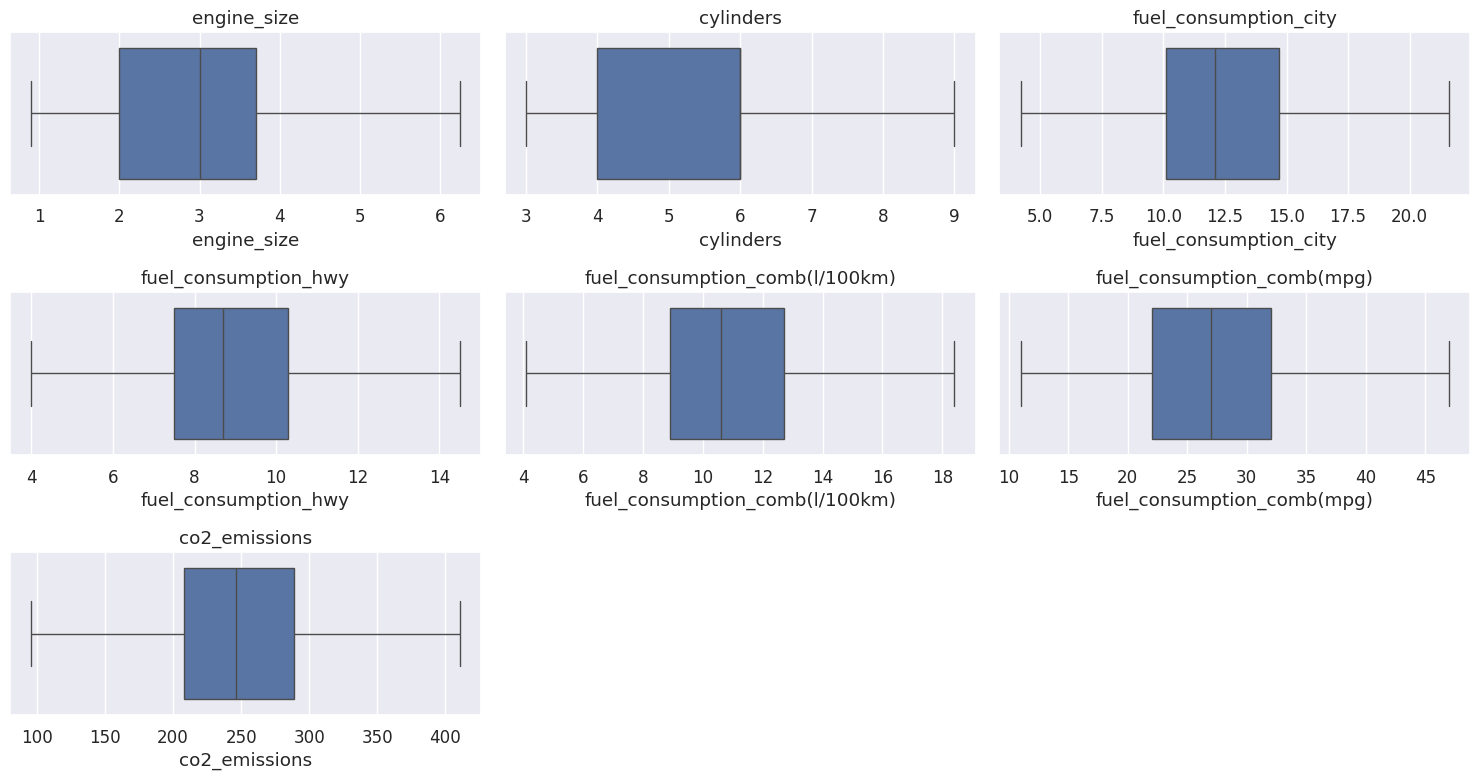

In [ ]:
plt.figure(figsize=(15,8))

for i,col in enumerate(num_cols):

    plt.subplot(3,3,i+1)

    sns.boxplot(x=df1[col])

    plt.title(col)

plt.tight_layout()

plt.show()

**9: Feature Engineering**

**Fuel Efficiency Ratio**

In [ ]:
df1["Fuel_Efficiency"] = (
    df1["fuel_consumption_city"] /
    df1["fuel_consumption_hwy"]
)

**Engine per Cylinder**

In [ ]:
df1["Engine_per_Cylinder"] = (
    df1["engine_size"] /
    df1["cylinders"]
)

**Average Fuel Consumption**

In [ ]:
df1["Average_Fuel"] = (
    df1["fuel_consumption_city"] +
    df1["fuel_consumption_hwy"]
)/2

**Cross Check**

In [ ]:
df1.head()

,make,model,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_consumption_city,fuel_consumption_hwy,fuel_consumption_comb(l/100km),fuel_consumption_comb(mpg),co2_emissions,Fuel_Efficiency,Engine_per_Cylinder,Average_Fuel
0,ACURA,ILX,COMPACT,2.0,4.0,AS,Z,9.9,6.7,8.5,33.0,196.0,1.477612,0.500000,8.30
1,ACURA,ILX,COMPACT,2.4,4.0,M,Z,11.2,7.7,9.6,29.0,221.0,1.454545,0.600000,9.45
2,ACURA,ILX HYBRID,COMPACT,1.5,4.0,AV,Z,6.0,5.8,5.9,47.0,136.0,1.034483,0.375000,5.90
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6.0,AS,Z,12.7,9.1,11.1,25.0,255.0,1.395604,0.583333,10.90
4,ACURA,RDX AWD,SUV - SMALL,3.5,6.0,AS,Z,12.1,8.7,10.6,27.0,244.0,1.390805,0.583333,10.40


**10: Separate Target Variable**

In [ ]:
X = df1.drop("co2_emissions",axis=1)

y = df1["co2_emissions"]

**11: Encode Categorical Variables**
ML models cannot understand text.
We convert text into numbers.

**Check Categorical Columns**

In [ ]:
cat_cols = X.select_dtypes(include="object").columns

cat_cols

Index(['make', 'model', 'vehicle_class', 'transmission', 'fuel_type'], dtype='object')

**One Hot Encoding**

In [ ]:
X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True
)

**12: Check Shape**

In [ ]:
print("Features :",X.shape)

print("Target :",y.shape)

Features : (6273, 2125)
Target : (6273,)


**13: Train Test Split**

80% → Training

20% → Testing

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42
)

**Verify**

In [ ]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(5018, 2125)
(1255, 2125)
(5018,)
(1255,)


**14: Feature Scaling**

Using :StandardScaler.

In [ ]:
#Import
from sklearn.preprocessing import StandardScaler


In [ ]:
#Create Object
scaler = StandardScaler()

**Fit on Training Data**

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)

**Transform Test Data**

In [ ]:
X_test_scaled = scaler.transform(X_test)

**15: Convert Back to DataFrame  (Optional)**

In [ ]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

**16: Save Scaler**

In [ ]:
import joblib

joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

**17: Final Verification**

In [ ]:
print("="*50)

print("Training Features :",X_train_scaled.shape)

print("Testing Features :",X_test_scaled.shape)

print("Training Target :",y_train.shape)

print("Testing Target :",y_test.shape)

print("="*50)

Training Features : (5018, 2125)
Testing Features : (1255, 2125)
Training Target : (5018,)
Testing Target : (1255,)


##**4 : MODEL BUILDING**

**Objective**

Train multiple Machine Learning Regression models and compare their performance.



**1 : Import Machine Learning Models**

In [ ]:
# Import Regression Models

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

**2 : Create Model Dictionary**

In [ ]:
models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(),

    "Lasso Regression": Lasso(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(random_state=42),

    "Extra Trees": ExtraTreesRegressor(random_state=42)

}

**3 : Create Empty Result Table**

In [ ]:
results = []

**4 : Train All Models**

In [ ]:
# Train every model and compare performance

for name, model in models.items():

    # Linear models use scaled features
    if name in ["Linear Regression","Ridge Regression","Lasso Regression"]:

        model.fit(X_train_scaled,y_train)

        prediction = model.predict(X_test_scaled)

    # Tree models use original features
    else:

        model.fit(X_train,y_train)

        prediction = model.predict(X_test)

    MAE = mean_absolute_error(y_test,prediction)

    MSE = mean_squared_error(y_test,prediction)

    RMSE = np.sqrt(MSE)

    R2 = r2_score(y_test,prediction)

    results.append([

        name,

        MAE,

        MSE,

        RMSE,

        R2

    ])

**5 : Model Comparison Table**

In [ ]:
result_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "MAE",

        "MSE",

        "RMSE",

        "R2 Score"

    ]

)

result_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,3.552257,27.297638,5.224714,0.992070
1,Ridge Regression,3.548386,27.612871,5.254795,0.991978
2,Lasso Regression,4.584499,62.434658,7.901560,0.981862
3,Decision Tree,2.404382,21.579792,4.645405,0.993731
4,Random Forest,2.357703,17.780521,4.216695,0.994835
5,Gradient Boosting,3.284511,27.199538,5.215318,0.992098
6,Extra Trees,2.274076,17.625851,4.198315,0.994880


**6 : Sort by Best R² Score**

In [ ]:
result_df = result_df.sort_values(

    by="R2 Score",

    ascending=False

)

result_df

,Model,MAE,MSE,RMSE,R2 Score
6,Extra Trees,2.274076,17.625851,4.198315,0.994880
4,Random Forest,2.357703,17.780521,4.216695,0.994835
3,Decision Tree,2.404382,21.579792,4.645405,0.993731
5,Gradient Boosting,3.284511,27.199538,5.215318,0.992098
0,Linear Regression,3.552257,27.297638,5.224714,0.992070
1,Ridge Regression,3.548386,27.612871,5.254795,0.991978
2,Lasso Regression,4.584499,62.434658,7.901560,0.981862


**7 : Visualize Model Performance**

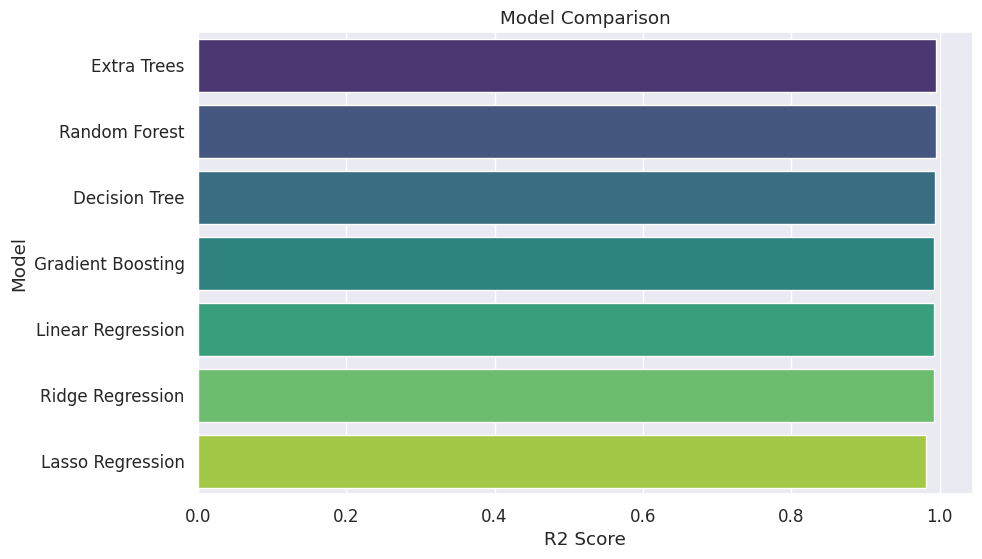

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=result_df,

    x="R2 Score",

    y="Model",

    palette="viridis"

)

plt.title("Model Comparison")

plt.show()

**8 : RMSE Comparison**

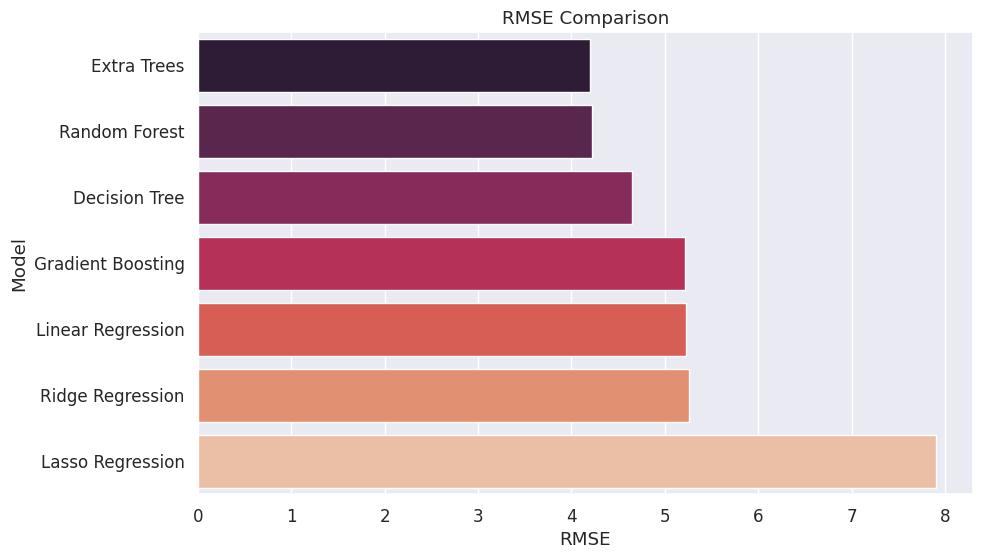

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=result_df,

    x="RMSE",

    y="Model",

    palette="rocket"

)

plt.title("RMSE Comparison")

plt.show()

**9 : Best Model**

In [ ]:
best_model_name = result_df.iloc[0]["Model"]

print(best_model_name)

Extra Trees


**Suppose Random Forest wins.**

In [ ]:
best_model = RandomForestRegressor(

    random_state=42

)

best_model.fit(

    X_train,

    y_train

)

RandomForestRegressor(random_state=42)

##**5 : MODEL EVALUATION**

**1 : Prediction**

In [ ]:
prediction = best_model.predict(X_test)

**2 : Evaluation Metrics**

In [ ]:
MAE = mean_absolute_error(y_test,prediction)

MSE = mean_squared_error(y_test,prediction)

RMSE = np.sqrt(MSE)

R2 = r2_score(y_test,prediction)

print("MAE :",MAE)

print("MSE :",MSE)

print("RMSE :",RMSE)

print("R2 :",R2)

MAE : 2.3577029406184784
MSE : 17.78052093189487
RMSE : 4.216695499072095
R2 : 0.9948346774963861


**MAE**

Average prediction error.

Lower is better.

**MSE**

Squares errors.

Punishes large mistakes.

**RMSE**

Same unit as target.

Most commonly reported.

**R² Score**

Closer to 1 means better model.

**3 : Actual vs Predicted**

In [ ]:
comparison = pd.DataFrame({

    "Actual":y_test,

    "Predicted":prediction

})

comparison.head(20)

,Actual,Predicted
3386,189.0,188.190000
2088,242.0,245.500000
3946,234.0,231.323333
1853,306.0,310.430000
5920,172.0,172.130500
672,290.0,291.552500
2734,285.0,280.046667
3513,172.0,171.100000
6278,169.0,167.869333
3251,244.0,240.505000


**4 : Scatter Plot**

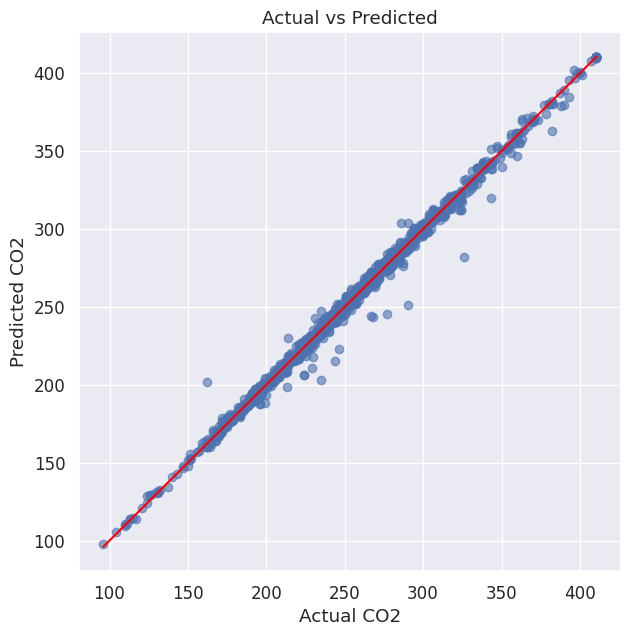

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(

    y_test,

    prediction,

    alpha=0.6

)

plt.xlabel("Actual CO2")

plt.ylabel("Predicted CO2")

plt.title("Actual vs Predicted")

plt.plot(

    [y_test.min(),y_test.max()],

    [y_test.min(),y_test.max()],

    color="red"

)

plt.show()

**5 : Residual Analysis**

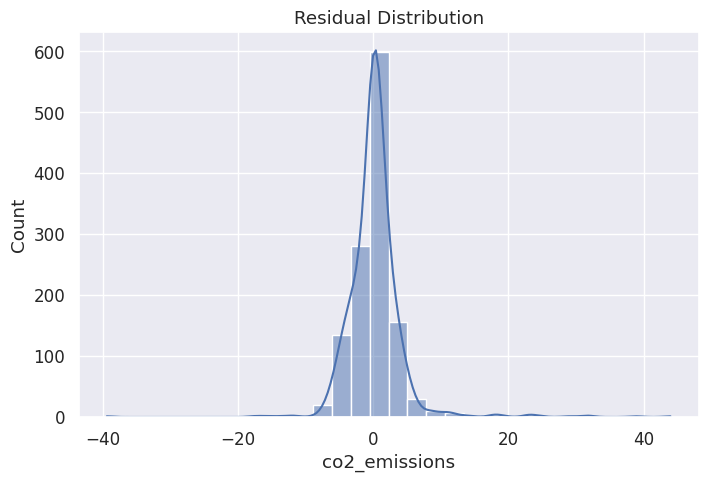

In [ ]:
residual = y_test-prediction

plt.figure(figsize=(8,5))

sns.histplot(

    residual,

    bins=30,

    kde=True

)

plt.title("Residual Distribution")

plt.show()

6 : Feature Importance (Random Fores)

In [ ]:
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
8,Average_Fuel,0.761631
4,fuel_consumption_comb(l/100km),0.141761
2121,fuel_type_E,0.049426
5,fuel_consumption_comb(mpg),0.023679
2,fuel_consumption_city,0.011853
0,engine_size,0.002789
2107,vehicle_class_PICKUP TRUCK - STANDARD,0.001111
956,model_FOCUS FFV,0.000940
7,Engine_per_Cylinder,0.000841
1,cylinders,0.000641


**Plot**

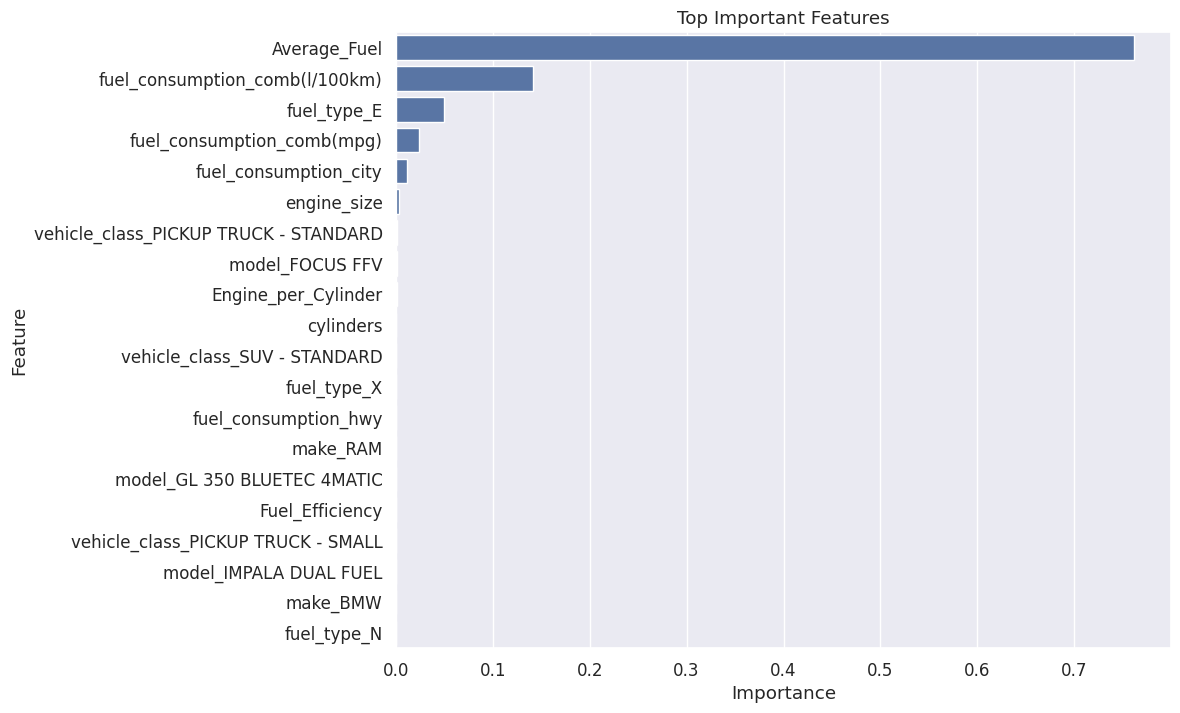

In [ ]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature"

)

plt.title("Top Important Features")

plt.show()

**6 : HYPERPARAMETER TUNING**

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
parameters = {
    "n_estimators": [100],
    "max_depth": [10, 20],
    "min_samples_split": [2]
}

In [ ]:
grid = GridSearchCV(

RandomForestRegressor(random_state=42),

parameters,

cv=5,

scoring="r2",

n_jobs=-1
)

grid.fit(

X_train,

y_train
)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20], 'min_samples_split': [2],
                         'n_estimators': [100]},
             scoring='r2')

In [ ]:
grid.best_params_

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

In [ ]:
best_model = grid.best_estimator_

**Evaluate again**

In [ ]:
prediction = best_model.predict(X_test)

print(r2_score(y_test,prediction))

0.9949876056381959


**7 : SAVE MODEL**

In [ ]:
import joblib

joblib.dump(

    best_model,

    "co2_model.pkl"

)

joblib.dump(

    scaler,

    "scaler.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully


**Test Saved Model**

In [ ]:
loaded_model = joblib.load(

    "co2_model.pkl"

)

loaded_model.predict(

    X_test.iloc[:5]

)

array([187.67006833, 243.83335023, 230.71538436, 310.30041751,
       171.37780564])